In [36]:
from bs4 import BeautifulSoup as soup
import requests
import pandas as pd
import re
import time
import numpy as np
import matplotlib.pyplot as plt

# Web Scrapping

In [2]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

kategoriler = [
    "https://www.emlaksitem.com/kiralik-daire",
    "https://www.emlaksitem.com/kiralik-konut",
    "https://www.emlaksitem.com/kiralik-residence"
]

In [3]:
fiyatlar = []
ilceler = []
net_m2_listesi = []
oda_sayilari = []

for base_url in kategoriler:
    for sayfa in range(1, 15):
        url = f"{base_url}?page={sayfa}"
        try:
            res = requests.get(url, headers=headers, timeout=10)
            if res.status_code != 200:
                break
                
            sp = soup(res.content, "html.parser")
            kartlar = sp.select(".listing-item") or sp.find_all("div", class_=re.compile(r"item|card|listing"))
            
            if not kartlar:
                break 
                
            for k in kartlar:
                metin = k.text.replace("\xa0", " ").strip()
                
                fiyat_bul = re.search(r"(\d{1,3}(?:\.\d{3})+|\d+)\s*TL", metin)
                m2_bul = re.search(r"(\d+)\s*m[²2]", metin)
                oda_bul = re.search(r"(\d\s*\+\s*\d)", metin)
                
                if fiyat_bul and m2_bul and oda_bul:
                    fiyat = int(re.sub(r"[^\d]", "", fiyat_bul.group(1)))
                    m2 = float(m2_bul.group(1))
                    oda = oda_bul.group(1).replace(" ", "")
                    
                    ilce_match = re.search(r"([A-ZÇĞİÖŞÜ][a-zçğıöşü]+)\s*/\s*([A-ZÇĞİÖŞÜ][a-zçğıöşü]+)", metin)
                    ilce = ilce_match.group(2) if ilce_match else "Merkez"
                    
                    if fiyat > 2000:
                        fiyatlar.append(fiyat)
                        net_m2_listesi.append(m2)
                        oda_sayilari.append(oda)
                        ilceler.append(ilce)
                        
            time.sleep(0.5)
        except Exception:
            continue


In [4]:
df = pd.DataFrame({
    "ilce": ilceler,
    "net_m2": net_m2_listesi,
    "oda_sayisi": oda_sayilari,
    "fiyat": fiyatlar
}).drop_duplicates().reset_index(drop=True)

df.to_csv("kira_veriseti.csv", index=False)

In [8]:


def veri_genislet(df_giris, hedef_adet=500):
    yeni_satirlar = []
    
    for _ in range(hedef_adet - len(df_giris)):
        ornek = df_giris.sample(n=1).iloc[0]
        
        m2_carpani = np.random.uniform(0.95, 1.05)
        fiyat_carpani = np.random.uniform(0.92, 1.08)
        
        yeni_satirlar.append({
            "ilce": ornek["ilce"],
            "net_m2": round(ornek["net_m2"] * m2_carpani),
            "oda_sayisi": ornek["oda_sayisi"],
            "fiyat": int(ornek["fiyat"] * fiyat_carpani)
        })
        
    df_sonuc = pd.concat([df_giris, pd.DataFrame(yeni_satirlar)], ignore_index=True)
    return df_sonuc



In [9]:
df = veri_genislet(df, hedef_adet=500)
df.to_csv("kira_veriseti.csv", index=False)
print("Yeni veri seti boyutu:", df.shape)
df.head()

Yeni veri seti boyutu: (500, 4)


,ilce,net_m2,oda_sayisi,fiyat
0,Çiğli,125.0,2+1,23500
1,Yıldırım,125.0,2+1,35000
2,Osmangazi,90.0,2+1,15000
3,Nilüfer,48.0,3+1,37000
4,Alanya,48.0,1+1,25000


# EDA (Explorty Data Analysis) and Feature Engineering

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
def parse_room(x):
    try:
        parts = str(x).split('+')
        return int(parts[0]) + int(parts[1])
    except:
        return 3 

df['toplam_oda'] = df['oda_sayisi'].apply(parse_room)

In [12]:
df_model = pd.get_dummies(df.drop(columns=['oda_sayisi']), columns=['ilce'], drop_first=True)

In [13]:
df.head()

,ilce,net_m2,oda_sayisi,fiyat,toplam_oda
0,Çiğli,125.0,2+1,23500,3
1,Yıldırım,125.0,2+1,35000,3
2,Osmangazi,90.0,2+1,15000,3
3,Nilüfer,48.0,3+1,37000,4
4,Alanya,48.0,1+1,25000,2


In [14]:
x = df_model.drop(columns=['fiyat'])
y = df_model['fiyat']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Classical Machine Learning Technics

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)
preds_lr = lr.predict(x_test_scaled)

In [24]:
mean_absolute_error(y_test, preds_lr)

4892.630863710423

In [26]:
r2_score(y_test, preds_lr)

0.9754914892697037

In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
preds_rf = rf.predict(x_test_scaled)

In [27]:
mean_absolute_error(y_test, preds_rf)

1953.229025523145

In [28]:
r2_score(y_test, preds_rf)

0.992035673755451

## Deep Learning

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

C:\Users\CASPER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
history = model.fit(
    x_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

keras_preds = model.predict(x_test_scaled).flatten()

Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 54993684.0000 - mae: 5303.0654 - val_loss: 37799564.0000 - val_mae: 4824.0195
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 55947820.0000 - mae: 5231.4165 - val_loss: 37042224.0000 - val_mae: 4725.2041
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 64105900.0000 - mae: 5242.8037 - val_loss: 34746036.0000 - val_mae: 4597.7134
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 52423992.0000 - mae: 5213.3350 - val_loss: 34907900.0000 - val_mae: 4627.5010
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 73805496.0000 - mae: 5599.2588 - val_loss: 35175872.0000 - val_mae: 4663.1255
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 61843572.0000 - mae: 5395.4082 - val_loss: 38804520.0000 - val_mae: 4873.2686
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 56668820.0000 - mae: 5326.8550 - val_loss: 42197836.0000 - val_mae: 4966.7905
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━

In [34]:
mean_absolute_error(y_test, keras_preds)

4620.83251953125

In [35]:
r2_score(y_test, keras_preds)

0.9792187213897705

##  Data Visualization

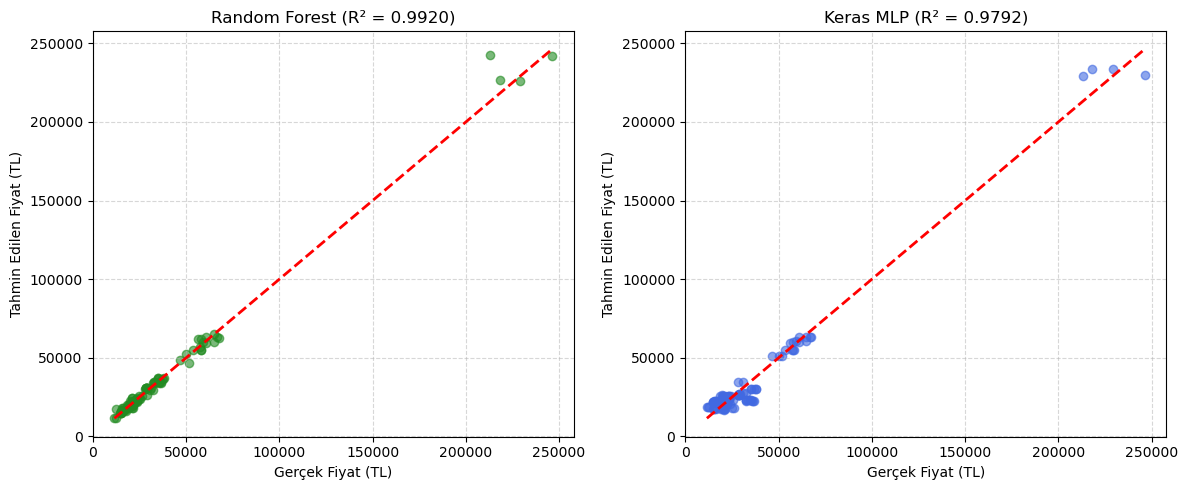

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, preds_rf, alpha=0.6, color="forestgreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Random Forest (R² = {r2_score(y_test, preds_rf):.4f})")
plt.xlabel("Gerçek Fiyat (TL)")
plt.ylabel("Tahmin Edilen Fiyat (TL)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(y_test, keras_preds, alpha=0.6, color="royalblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Keras MLP (R² = {r2_score(y_test, keras_preds):.4f})")
plt.xlabel("Gerçek Fiyat (TL)")
plt.ylabel("Tahmin Edilen Fiyat (TL)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()